## INTRODUCTION

Proyek ini difokuskan untuk mengembangkan model Custom CNN yang mampu mengklasifikasikan gambar lesi kulit secara multi-kelas terhadap kategori-kategori penyakit kulit tertentu dengan harapan model tersebut dapat berguna sebagai langkah awal dalam menciptakan sebuah sistem pendeteksi dini penyakit kulit.

Oleh:
- Achmad Baihaqie Wibowo (103012400026)
- Bayu Alif Aryo Wiputra (103012)

Catatan:
- `notebook_01_EDA.ipynb` difokuskan sebagai wadah untuk melaksanakan tahap eksplorasi dan analisis terhadap dataset.
- `notebook_02_DEVELOPMENT.ipynb` difokuskan sebagai wadah untuk mengabstraksikan tahap *data preparation* dan pengembangan model.
- `notebook_03_EXECUTION.ipynb` difokuskan sebagai wadah untuk melaksanakan/menjalankan *workflow* dari `notebook_02_DEVELOPMENT.ipynb` dengan memanfaatkan ketersediaan GPU.
- tautan dataset: https://www.kaggle.com/datasets/kmader/skin-cancer-mnist-ham10000

## Training and Evaluation

Using device: cuda
train set: 7979 | val set: 1012 | test set: 1024
jumlah ID bocor antara train set dan validation set: 0
jumlah ID bocor antara train set dan test set: 0

proporsi tiap kelas dalam train set:
dx
nv       5337
mel       885
bkl       884
bcc       412
akiec     258
vasc      114
df         89
Name: count, dtype: int64
tipe data target label_idx: int64
metadata features: ['age_scaled', 'sex_female', 'sex_male', 'sex_unknown', 'localization_abdomen', 'localization_acral', 'localization_back', 'localization_chest', 'localization_ear', 'localization_face', 'localization_foot', 'localization_genital', 'localization_hand', 'localization_lower extremity', 'localization_neck', 'localization_scalp', 'localization_trunk', 'localization_unknown', 'localization_upper extremity']


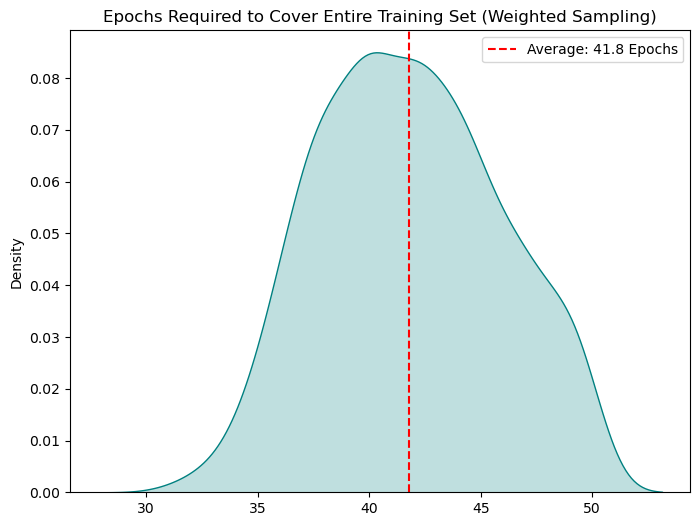

SkinCancerCNN(
  (block1): DoubleConvBlock(
    (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (bn1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (conv2): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (bn2): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (block2): DoubleConvBlock(
    (conv1): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (block3): DoubleConvBlock(
    (conv1): Conv2d(64, 128, kernel_s

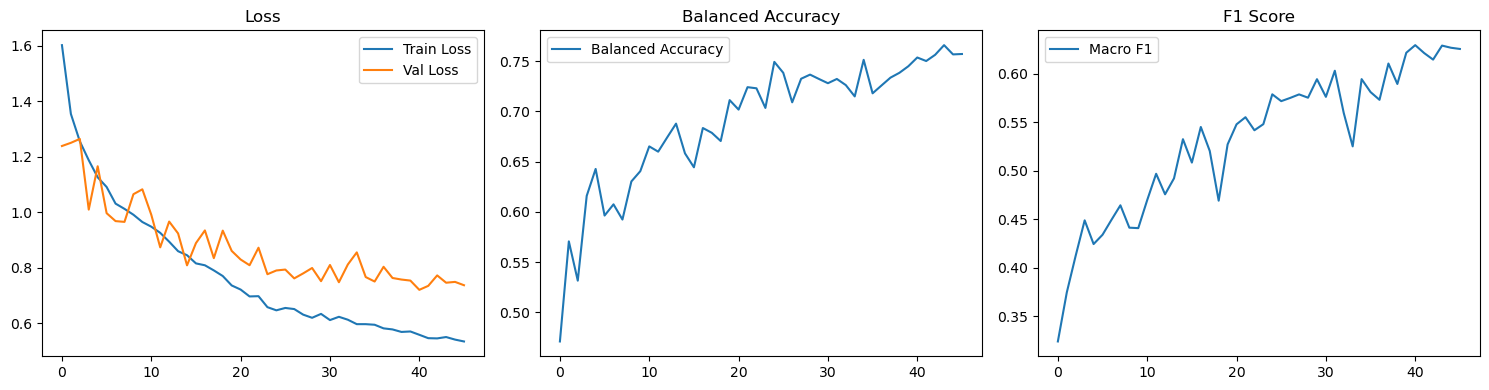


Evaluating best_loss model: ham10000_CNN_best_loss.pth
Balanced Accuracy: 0.6408
Macro F1 Score: 0.5331

Classification Report:
              precision    recall  f1-score   support

       akiec       0.33      0.76      0.46        33
         bcc       0.46      0.60      0.52        53
         bkl       0.49      0.50      0.50       105
          df       0.30      0.54      0.39        13
         mel       0.37      0.60      0.46       115
          nv       0.96      0.75      0.84       690
        vasc       0.46      0.73      0.56        15

    accuracy                           0.70      1024
   macro avg       0.48      0.64      0.53      1024
weighted avg       0.78      0.70      0.72      1024



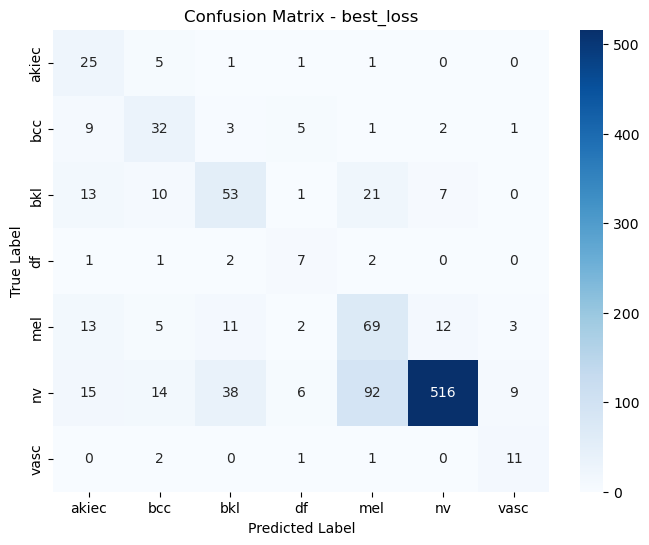


Evaluating best_bal_acc model: ham10000_CNN_best_bal_acc.pth
Balanced Accuracy: 0.6484
Macro F1 Score: 0.5380

Classification Report:
              precision    recall  f1-score   support

       akiec       0.38      0.76      0.51        33
         bcc       0.44      0.70      0.54        53
         bkl       0.48      0.45      0.46       105
          df       0.30      0.54      0.39        13
         mel       0.36      0.63      0.45       115
          nv       0.96      0.74      0.84       690
        vasc       0.48      0.73      0.58        15

    accuracy                           0.69      1024
   macro avg       0.49      0.65      0.54      1024
weighted avg       0.78      0.69      0.72      1024



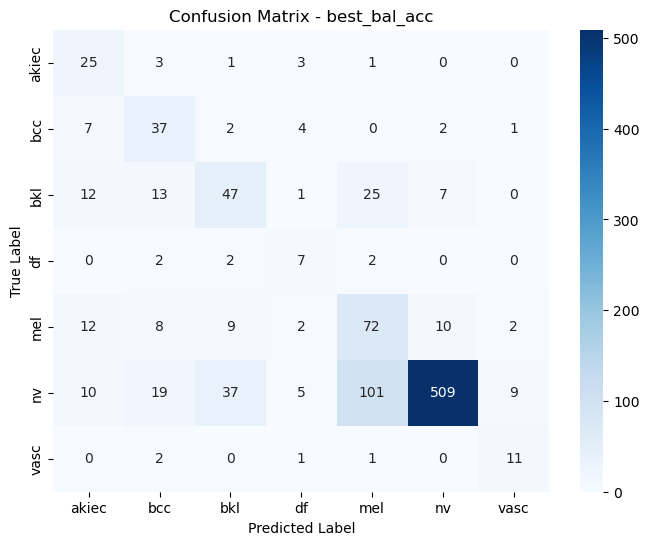


Evaluating best_f1 model: ham10000_CNN_best_f1.pth
Balanced Accuracy: 0.6408
Macro F1 Score: 0.5331

Classification Report:
              precision    recall  f1-score   support

       akiec       0.33      0.76      0.46        33
         bcc       0.46      0.60      0.52        53
         bkl       0.49      0.50      0.50       105
          df       0.30      0.54      0.39        13
         mel       0.37      0.60      0.46       115
          nv       0.96      0.75      0.84       690
        vasc       0.46      0.73      0.56        15

    accuracy                           0.70      1024
   macro avg       0.48      0.64      0.53      1024
weighted avg       0.78      0.70      0.72      1024



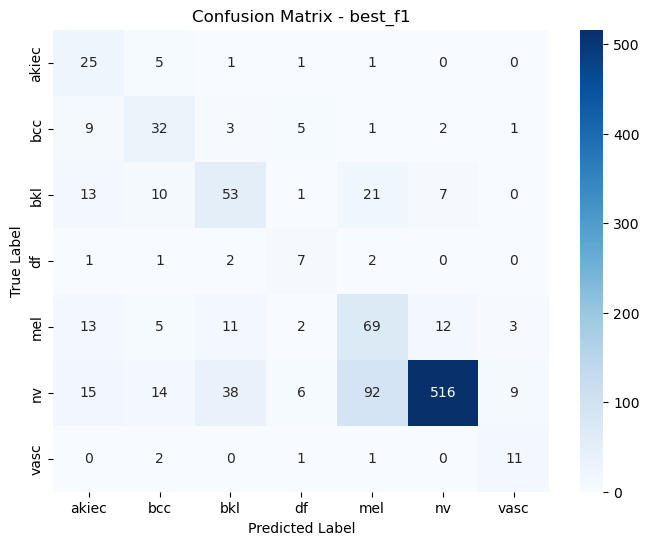

In [1]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from glob import glob
from PIL import Image
import warnings
warnings.filterwarnings('ignore')

# PyTorch
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
import torch.optim as optim
from torch.optim.lr_scheduler import ReduceLROnPlateau
import torchvision.transforms as transforms

# sklearn
from sklearn.model_selection import train_test_split
from sklearn.metrics import balanced_accuracy_score, f1_score, classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler

# ---------- Global settings (remain outside main) ----------
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

if torch.cuda.is_available():
    torch.backends.cudnn.benchmark = True

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)

# ---------- Data handling functions ----------
def run_coverage_simulation(df, trials=1000, max_eps=50):
    counts = df['label_idx'].value_counts().sort_index().values
    class_weights = 1. / torch.tensor(counts, dtype=torch.float)
    sample_weights = class_weights[df['label_idx'].values]
    probs = sample_weights / sample_weights.sum()
    n_samples = len(probs)
    results = []
    for _ in range(trials):
        seen = set()
        for epoch in range(1, max_eps + 1):
            drawn_indices = torch.multinomial(probs, n_samples, replacement=True).tolist()
            seen.update(drawn_indices)
            if len(seen) == n_samples:
                results.append(epoch)
                break
    return results

class HAM10000Dataset(Dataset):
    def __init__(self, dataframe, metadata_cols, transform=None):
        self.df = dataframe.reset_index(drop=True)
        self.metadata_cols = metadata_cols
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        img_path = self.df.iloc[idx]['image_path']
        image = Image.open(img_path).convert('RGB')
        label = self.df.iloc[idx]['label_idx']
        label = torch.tensor(label, dtype=torch.long)
        meta = self.df.iloc[idx][self.metadata_cols].values.astype(np.float32)
        meta = torch.tensor(meta, dtype=torch.float32)

        if self.transform:
            image = self.transform(image)
        return image, meta, label

# ---------- Model definitions ----------
class DoubleConvBlock(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.conv1 = nn.Conv2d(in_channels, out_channels, 3, padding=1)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.conv2 = nn.Conv2d(out_channels, out_channels, 3, padding=1)
        self.bn2 = nn.BatchNorm2d(out_channels)
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

    def forward(self, x):
        x = F.leaky_relu(self.bn1(self.conv1(x)))
        x = F.leaky_relu(self.bn2(self.conv2(x)))
        x = self.pool(x)
        return x

class SkinCancerCNN(nn.Module):
    def __init__(self, n_metadata):
        super().__init__()
        self.block1 = DoubleConvBlock(3, 32)
        self.block2 = DoubleConvBlock(32, 64)
        self.block3 = DoubleConvBlock(64, 128)
        self.block4 = DoubleConvBlock(128, 256)
        self.adaptive_pool = nn.AdaptiveAvgPool2d((4, 4))
        self.flatten_size = 256 * 4 * 4
        self.fc1 = nn.Linear(self.flatten_size, 128)
        self.bn3 = nn.BatchNorm1d(128)
        self.dropout = nn.Dropout(0.5)
        self.fc2 = nn.Linear(128 + n_metadata, 7)

    def forward(self, x, meta):
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)
        x = self.block4(x)
        x = self.adaptive_pool(x)
        x = x.view(x.size(0), -1)
        x = F.leaky_relu(self.bn3(self.fc1(x)))
        x = self.dropout(x)
        combined = torch.cat((x, meta), dim=1)
        x = self.fc2(combined)
        return x

class MultiMetricCheckpoint:
    def __init__(self, patience=7, path_prefix='ham10000_focalLoss'):
        self.patience = patience
        self.counter = 0
        self.best_loss = np.inf
        self.best_bal_acc = 0.0
        self.best_f1 = 0.0
        self.early_stop = False
        self.path_prefix = path_prefix
        
    def __call__(self, val_loss, val_labels, val_preds, model):
        bal_acc = balanced_accuracy_score(val_labels, val_preds)
        f1 = f1_score(val_labels, val_preds, average='macro')
        if val_loss < self.best_loss:
            print(f"Loss Membaik: {self.best_loss:.4f} -> {val_loss:.4f}. Simpan model_best_loss.pth")
            self.best_loss = val_loss
            torch.save(model.state_dict(), f'{self.path_prefix}_best_loss.pth')
            self.counter = 0
        else:
            self.counter += 1
            print(f"Loss tidak membaik. EarlyStop Counter: {self.counter}/{self.patience}")
        if bal_acc > self.best_bal_acc:
            print(f"Bal. Acc Membaik: {self.best_bal_acc:.4f} -> {bal_acc:.4f}. Simpan model_best_bal_acc.pth")
            self.best_bal_acc = bal_acc
            torch.save(model.state_dict(), f'{self.path_prefix}_best_bal_acc.pth')
        if f1 > self.best_f1:
            print(f"F1-Score Membaik: {self.best_f1:.4f} -> {f1:.4f}. Simpan model_best_f1.pth")
            self.best_f1 = f1
            torch.save(model.state_dict(), f'{self.path_prefix}_best_f1.pth')
        if self.counter >= self.patience:
            self.early_stop = True 
        return bal_acc, f1

def evaluate_model(model_path, loader, device, n_metadata):
    model = SkinCancerCNN(n_metadata).to(device)
    model.load_state_dict(torch.load(model_path, map_location=device))
    model.eval()
    all_labels = []
    all_preds = []
    with torch.no_grad():
        for images, meta, labels in loader:
            images = images.to(device, non_blocking=True)
            meta = meta.to(device, non_blocking=True)
            outputs = model(images, meta)
            preds = torch.argmax(outputs, dim=1)
            all_labels.extend(labels.numpy())
            all_preds.extend(preds.cpu().numpy())
    return np.array(all_labels), np.array(all_preds)

# ---------- Main script (wrapped for Windows) ----------
def main():
    set_seed(42)

    BASE_DIR = 'data'
    metadata_path = os.path.join(BASE_DIR, 'HAM10000_metadata.csv')
    image_folders = [
        os.path.join(BASE_DIR, 'HAM10000_images_part_1'),
        os.path.join(BASE_DIR, 'HAM10000_images_part_2')
    ]
    image_id_path_dict = {os.path.splitext(os.path.basename(x))[0]: x for folder in image_folders for x in glob(os.path.join(folder, "*.jpg"))}

    df_metadata = pd.read_csv(metadata_path)
    df_metadata['image_path'] = df_metadata['image_id'].map(image_id_path_dict)

    # split data
    df_unique_lesions = df_metadata.drop_duplicates(subset='lesion_id')
    ids_train_val, ids_test = train_test_split(df_unique_lesions['lesion_id'], test_size=0.10, stratify=df_unique_lesions['dx'], random_state=42)
    df_unique_train_val = df_unique_lesions[df_unique_lesions['lesion_id'].isin(ids_train_val)]
    ids_train, ids_val = train_test_split(df_unique_train_val['lesion_id'], test_size=10/90, stratify=df_unique_train_val['dx'], random_state=42)
    df_train = df_metadata[df_metadata['lesion_id'].isin(ids_train)].copy().reset_index(drop=True)
    df_val = df_metadata[df_metadata['lesion_id'].isin(ids_val)].copy().reset_index(drop=True)
    df_test = df_metadata[df_metadata['lesion_id'].isin(ids_test)].copy().reset_index(drop=True)

    print(f"train set: {len(df_train)} | val set: {len(df_val)} | test set: {len(df_test)}")
    overlap_train_val = set(df_train['lesion_id']).intersection(set(df_val['lesion_id']))
    print(f"jumlah ID bocor antara train set dan validation set: {len(overlap_train_val)}")
    overlap_train_test = set(df_train['lesion_id']).intersection(set(df_test['lesion_id']))
    print(f"jumlah ID bocor antara train set dan test set: {len(overlap_train_test)}")

    print("\nproporsi tiap kelas dalam train set:")
    print(df_train['dx'].value_counts())

    # handle missing values
    df_train.loc[df_train['age'] < 0, 'age'] = np.nan
    train_age_median_mapping = df_train.groupby('dx')['age'].median()
    for df in [df_train, df_val, df_test]:
        df['age'] = df['age'].fillna(df['dx'].map(train_age_median_mapping))

    # feature scaling
    scaler = StandardScaler()
    df_train['age_scaled'] = scaler.fit_transform(df_train[['age']])
    df_val['age_scaled'] = scaler.transform(df_val[['age']])
    df_test['age_scaled'] = scaler.transform(df_test[['age']])

    # label encoding
    manual_map = {'akiec':0, 'bcc':1, 'bkl':2, 'df':3, 'mel':4, 'nv':5, 'vasc':6}
    for df in [df_train, df_val, df_test]:
        df['label_idx'] = df['dx'].map(manual_map).astype(int)
    print(f"tipe data target label_idx: {df_train['label_idx'].dtype}")

    # one-hot encoding
    ohe_columns = ['sex', 'localization']
    df_train = pd.get_dummies(df_train, columns=ohe_columns)
    df_val = pd.get_dummies(df_val, columns=ohe_columns)
    df_test = pd.get_dummies(df_test, columns=ohe_columns)

    for df in [df_train, df_val, df_test]:
        for col in df_train.columns:
            if col not in df.columns:
                df[col] = 0
    df_train = df_train[df_train.columns]
    df_val = df_val[df_train.columns]
    df_test = df_test[df_train.columns]

    # drop unnecessary columns
    drop_cols = ['lesion_id', 'image_id', 'dx', 'dx_type', 'age']
    for df in [df_train, df_val, df_test]:
        cols_to_drop = [c for c in drop_cols if c in df.columns]
        df.drop(columns=cols_to_drop, inplace=True)

    metadata_features = [col for col in df_train.columns if col not in ['label_idx', 'image_path']]
    print(f"metadata features: {metadata_features}")
    n_metadata = len(metadata_features)

    # transforms
    train_transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.RandomHorizontalFlip(),
        transforms.RandomVerticalFlip(),
        transforms.RandomRotation(360),
        transforms.RandomAffine(degrees=0, translate=(0.1, 0.1), scale=(0.9, 1.1)),
        transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0),
        transforms.ToTensor(),
        transforms.RandomErasing(p=0.5, scale=(0.02, 0.1), ratio=(0.3, 3.3)),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])
    val_test_transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])

    # datasets and loaders
    train_dataset = HAM10000Dataset(df_train, metadata_features, transform=train_transform)
    val_dataset = HAM10000Dataset(df_val, metadata_features, transform=val_test_transform)
    test_dataset = HAM10000Dataset(df_test, metadata_features, transform=val_test_transform)

    class_counts = df_train['label_idx'].value_counts().sort_index().values
    class_weights = 1. / torch.tensor(class_counts, dtype=torch.float)
    sample_weights = [class_weights[label] for label in df_train['label_idx']]
    sampler = WeightedRandomSampler(weights=sample_weights, num_samples=len(sample_weights), replacement=True)

    train_loader = DataLoader(train_dataset, batch_size=64, sampler=sampler, num_workers=0, pin_memory=True)
    val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False, num_workers=0, pin_memory=True)
    test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False, num_workers=0, pin_memory=True)

    # coverage simulation
    needed_epochs = run_coverage_simulation(df_train)
    plt.figure(figsize=(8, 6))
    sns.kdeplot(needed_epochs, fill=True, color="teal")
    plt.axvline(np.mean(needed_epochs), color='red', linestyle='--', label=f'Average: {np.mean(needed_epochs):.1f} Epochs')
    plt.title("Epochs Required to Cover Entire Training Set (Weighted Sampling)")
    plt.legend()
    plt.show()

    # model and training setup
    model = SkinCancerCNN(n_metadata).to(device)
    print(model)

    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-2)
    scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)
    scaler_amp = torch.amp.GradScaler(device='cuda') if torch.cuda.is_available() else None
    checkpoint_handler = MultiMetricCheckpoint(patience=18, path_prefix='ham10000_CNN')
    epochs = int(np.mean(needed_epochs)) + 5

    history = {'train_loss': [], 'val_loss': [], 'bal_acc': [], 'f1': []}

    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        for images, meta, labels in train_loader:
            images = images.to(device, non_blocking=True)
            meta = meta.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            optimizer.zero_grad()
            if scaler_amp:
                with torch.amp.autocast(device_type='cuda'):
                    outputs = model(images, meta)
                    loss = criterion(outputs, labels)
                scaler_amp.scale(loss).backward()
                scaler_amp.step(optimizer)
                scaler_amp.update()
            else:
                outputs = model(images, meta)
                loss = criterion(outputs, labels)
                loss.backward()
                optimizer.step()

            running_loss += loss.item() * images.size(0)

        epoch_train_loss = running_loss / len(train_dataset)
        history['train_loss'].append(epoch_train_loss)

        model.eval()
        val_loss = 0.0
        all_labels = []
        all_preds = []
        with torch.no_grad():
            for images, meta, labels in val_loader:
                images = images.to(device, non_blocking=True)
                meta = meta.to(device, non_blocking=True)
                labels = labels.to(device, non_blocking=True)
                outputs = model(images, meta)
                loss = criterion(outputs, labels)
                val_loss += loss.item() * images.size(0)

                preds = torch.argmax(outputs, dim=1)
                all_labels.extend(labels.cpu().numpy())
                all_preds.extend(preds.cpu().numpy())

        epoch_val_loss = val_loss / len(val_dataset)
        history['val_loss'].append(epoch_val_loss)

        bal_acc, f1 = checkpoint_handler(epoch_val_loss, all_labels, all_preds, model)
        history['bal_acc'].append(bal_acc)
        history['f1'].append(f1)

        scheduler.step(epoch_val_loss)

        print(f"Epoch {epoch+1}/{epochs} | Train Loss: {epoch_train_loss:.4f} | Val Loss: {epoch_val_loss:.4f} | Bal Acc: {bal_acc:.4f} | F1: {f1:.4f}")

        if checkpoint_handler.early_stop:
            print("Early stopping triggered.")
            break

    # plot training history
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    axes[0].plot(history['train_loss'], label='Train Loss')
    axes[0].plot(history['val_loss'], label='Val Loss')
    axes[0].set_title('Loss')
    axes[0].legend()
    axes[1].plot(history['bal_acc'], label='Balanced Accuracy')
    axes[1].set_title('Balanced Accuracy')
    axes[1].legend()
    axes[2].plot(history['f1'], label='Macro F1')
    axes[2].set_title('F1 Score')
    axes[2].legend()
    plt.tight_layout()
    plt.show()

    # evaluate best models on test set
    model_paths = {
        'best_loss': 'ham10000_CNN_best_loss.pth',
        'best_bal_acc': 'ham10000_CNN_best_bal_acc.pth',
        'best_f1': 'ham10000_CNN_best_f1.pth'
    }
    class_names = ['akiec', 'bcc', 'bkl', 'df', 'mel', 'nv', 'vasc']

    for name, path in model_paths.items():
        if os.path.exists(path):
            print(f"\nEvaluating {name} model: {path}")
            y_true, y_pred = evaluate_model(path, test_loader, device, n_metadata)
            bal_acc = balanced_accuracy_score(y_true, y_pred)
            f1 = f1_score(y_true, y_pred, average='macro')
            print(f"Balanced Accuracy: {bal_acc:.4f}")
            print(f"Macro F1 Score: {f1:.4f}")
            print("\nClassification Report:")
            print(classification_report(y_true, y_pred, target_names=class_names))

            cm = confusion_matrix(y_true, y_pred)
            plt.figure(figsize=(8, 6))
            sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
            plt.title(f'Confusion Matrix - {name}')
            plt.ylabel('True Label')
            plt.xlabel('Predicted Label')
            plt.show()
        else:
            print(f"model file {path} not found. Skipping.")

# ---------- Entry point for Windows compatibility ----------
if __name__ == "__main__":
    main()